فصل اول: سیگنال، ریاضیات و ابزارها

درس 3:

# 🧩 دیدن صدا با اسپکتروگرام (Spectrogram)



### 1️⃣ نصب و وارد کردن کتابخانه‌ها

In [3]:
%pip install -v -i https://mirror-pypi.runflare.com/simple librosa soundfile matplotlib sounddevice numpy scipy --trusted-host mirror-pypi.runflare.com

Using pip 24.0 from c:\Users\mosta\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)
Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
import scipy.signal as signal

### 2️⃣ ضبط یک جمله کامل برای تحلیل

In [5]:
duration = 4  
sr = 44100

print(" 🎙️ درحال ضبط... لطفا یک جمله بگویید")
recording = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
print("ضبط با موفقیت انجام شد")

sf.write("sentence.wav", recording, sr)
print("ذخیره شد 'sentence.wav' فایل با نام")

 🎙️ درحال ضبط... لطفا یک جمله بگویید
ضبط با موفقیت انجام شد
ذخیره شد 'sentence.wav' فایل با نام


### 3️⃣ مشکل فوریه: زمان کجاست؟

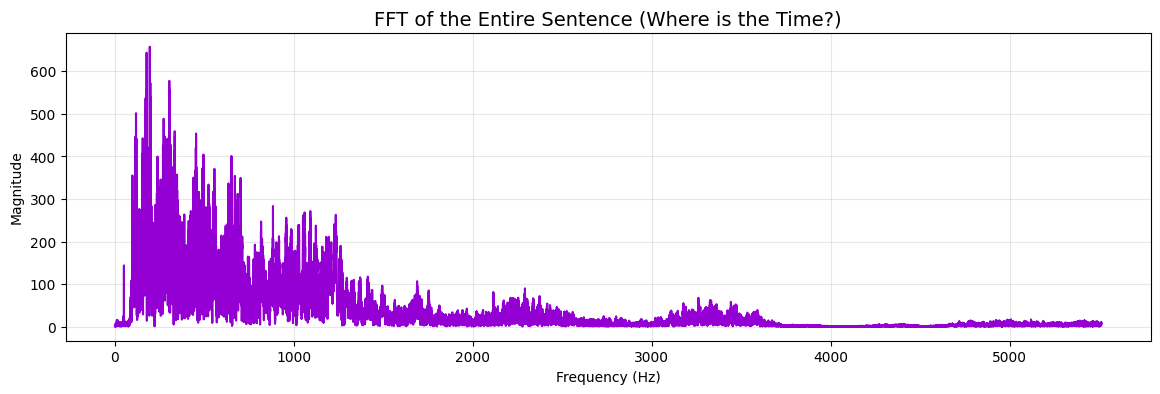

In [6]:
y, sr = librosa.load("sentence.wav", sr=None)

fft_result = np.fft.fft(y)
fft_magnitude = np.abs(fft_result)
freqs = np.fft.fftfreq(len(fft_result), d=1/sr)

plt.figure(figsize=(14,4))
plt.plot(freqs[:len(freqs)//8], fft_magnitude[:len(freqs)//8], color='darkviolet')
plt.title("FFT of the Entire Sentence (Where is the Time?)", fontsize=14)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.show()

### 4️⃣ جادوی پنجره‌بندی (Windowing)

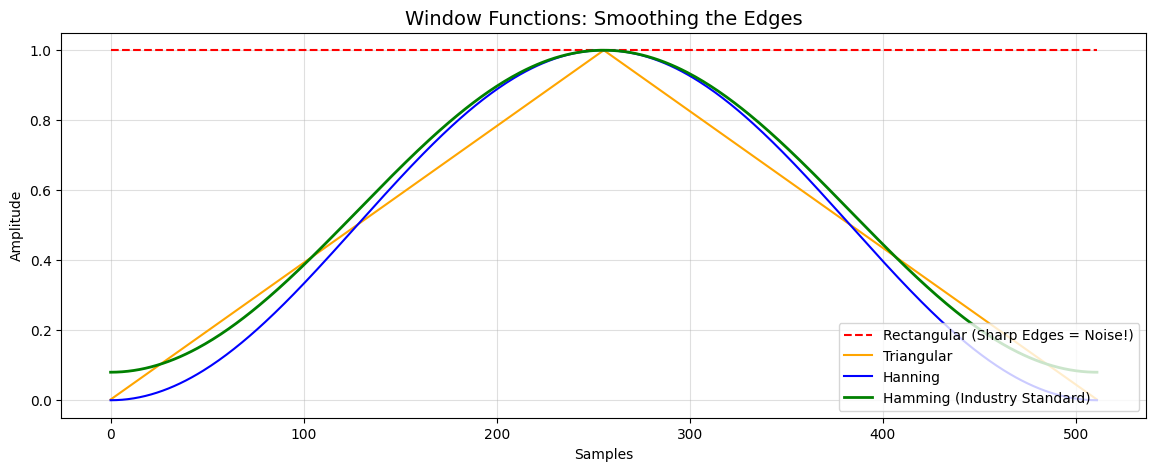

In [7]:
window_length = 512

# ساخت انواع پنجره‌ها
window_rect = np.ones(window_length)                     # مستطیلی
window_tri = signal.windows.triang(window_length)        # مثلثی
window_hann = np.hanning(window_length)                  # هنینگ
window_hamm = np.hamming(window_length)                  # همینگ

plt.figure(figsize=(14, 5))
plt.plot(window_rect, label="Rectangular (Sharp Edges = Noise!)", color='red', linestyle='--')
plt.plot(window_tri, label="Triangular", color='orange')
plt.plot(window_hann, label="Hanning", color='blue')
plt.plot(window_hamm, label="Hamming (Industry Standard)", color='green', linewidth=2)

plt.title("Window Functions: Smoothing the Edges", fontsize=14)
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.4)
plt.show()

### 5️⃣ ترکیب نهایی و خلق اسپکتروگرام

In [8]:
# n_fft: طول هر پنجره 
# hop_length: میزان پرش پنجره به جلو (همپوشانی)
# window: نوع پنجره (پیش‌فرض هنینگ/همینگ است)

D = librosa.stft(y, n_fft=2048, hop_length=512, window='hamming')

# چون گوش انسان شدت صدا را به صورت لگاریتمی می‌شنود، دامنه‌ها را به دسی‌بل تبدیل می‌کنیم
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print(f"ابعاد ماتریس اسپکتروگرام: {S_db.shape}")
print("محور عمودی: فرکانس | محور افقی: زمان | مقادیر داخل ماتریس: شدت رنگ‌ها")

ابعاد ماتریس اسپکتروگرام: (1025, 345)
محور عمودی: فرکانس | محور افقی: زمان | مقادیر داخل ماتریس: شدت رنگ‌ها


### 6️⃣ دیدن صدا: رسم اثر انگشت صوتی

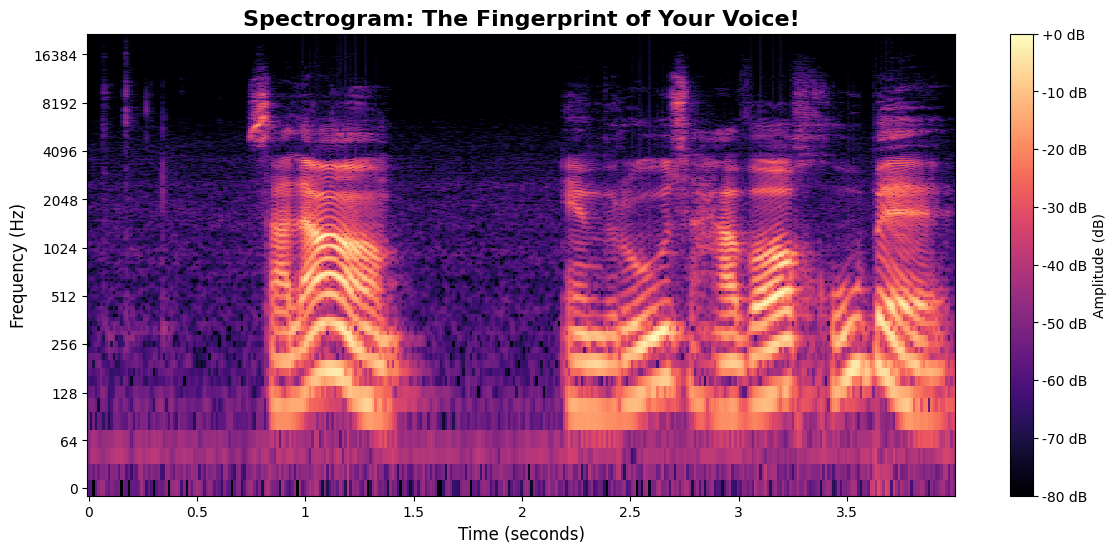

In [9]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='log', cmap='magma')

plt.colorbar(format='%+2.0f dB', label="Amplitude (dB)")
plt.title("Spectrogram: The Fingerprint of Your Voice!", fontsize=16, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)
plt.show()

### 7️⃣ مقایسه نهایی: نمودار زمانی در برابر اسپکتروگرام

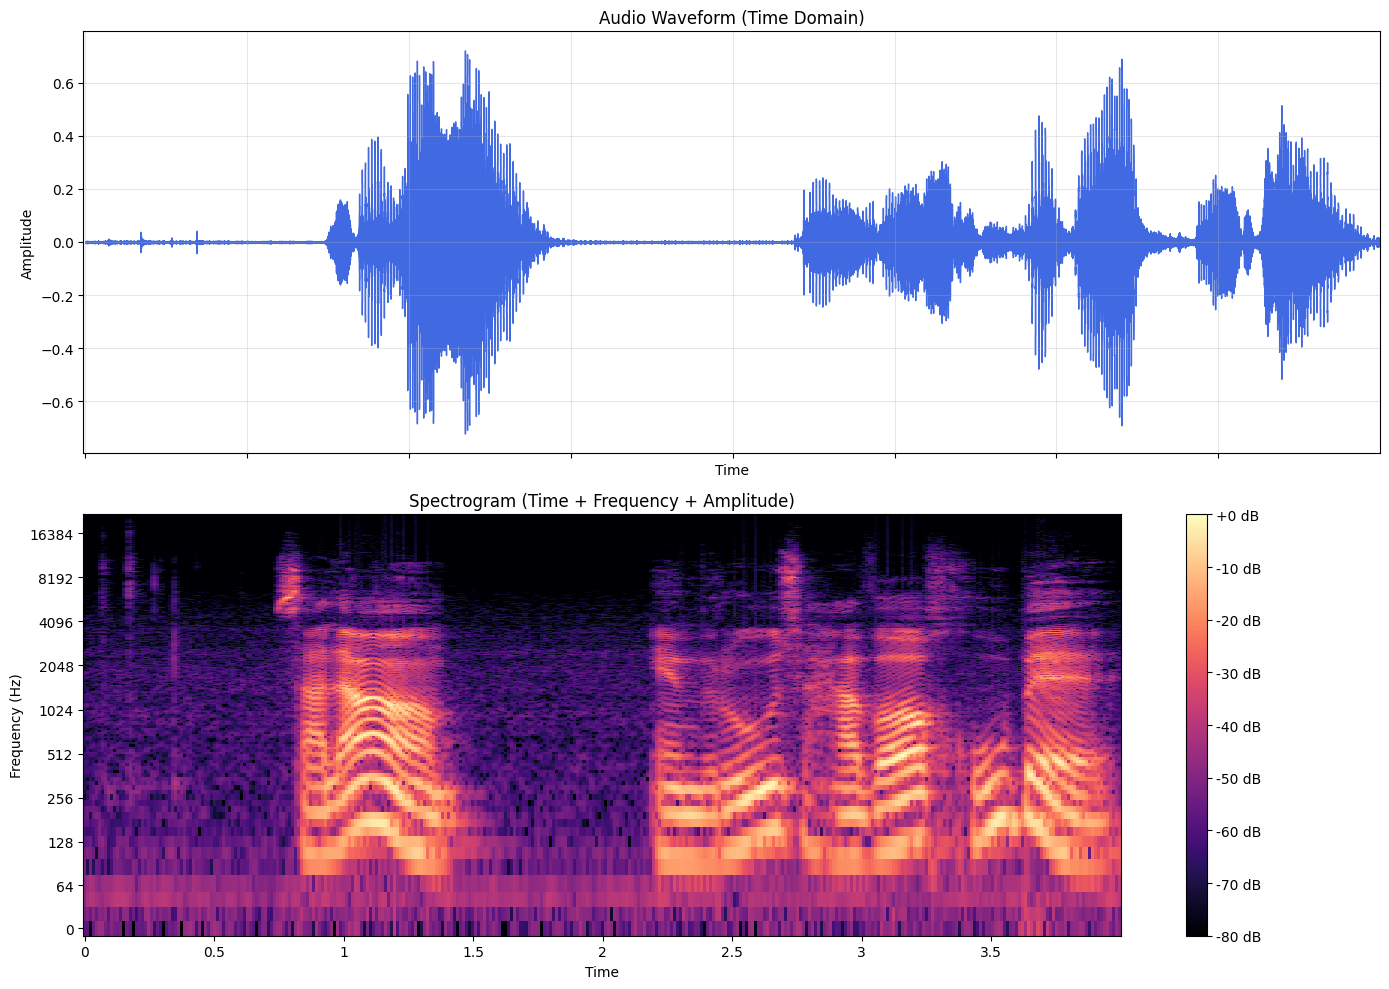

In [10]:

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# رسم Waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0], color='royalblue')
ax[0].set(title='Audio Waveform (Time Domain)', ylabel='Amplitude')
ax[0].grid(True, alpha=0.3)

# رسم Spectrogram
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', ax=ax[1], cmap='magma')
ax[1].set(title='Spectrogram (Time + Frequency + Amplitude)', ylabel='Frequency (Hz)')
fig.colorbar(img, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

### 🏁 جمع‌بندی




امروز یک قدم بزرگ در پردازش سیگنال برداشتیم:

- فهمیدیم **تبدیل فوریه** زمان را از بین می‌برد و برای تحلیل گفتار کافی نیست
- با **نشت طیفی** و نیاز به بریدنِ نرم سیگنال آشنا شدیم
- **توابع پنجره‌بندی** را بررسی کردیم
- زمان را به فرکانس گره زدیم و **اسپکتروگرام** را ساختیم
- حالا ما می‌توانیم کلمات را قبل از شنیدن، از روی الگوهای رنگی‌شان ببینیم!

**درس بعدی:**  
MFCC اثر انگشت صوتی: شبیه‌سازی گوش انسان با  
